In [1]:
from google.colab import files # чтобы загружать файлы в облако через проводник

In [2]:
uploaded = files.upload()#просто запускаем и выбираем файл  API токена в проводнике

#↓ строка которая активирует наш API токен
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [3]:
!kaggle competitions download -c urfusf2024clustering

  0% 0.00/953k [00:00<?, ?B/s]
100% 953k/953k [00:00<00:00, 852MB/s]


In [4]:
!unzip urfusf2024clustering.zip

Archive:  urfusf2024clustering.zip
  inflating: Data.csv                
  inflating: Submission.csv          


In [5]:
import pandas as pd # Библиотека Pandas для работы с табличными данными

In [6]:
DF = pd.read_csv('/content/Data.csv', delimiter = ',', index_col = 'idx')
DF

,Признак 1,Признак 2,Признак 3,Признак 4,Признак 5
idx,,,,,
0,-0.179369,-0.013356,0.016641,-0.325923,-0.031094
1,-0.157893,-0.010647,0.002895,-0.332016,-0.012547
2,-0.249451,-0.011700,-0.001435,-0.487909,-0.005343
3,-0.158938,0.210980,0.021905,-0.334196,-0.013976
4,-0.687836,0.422630,0.054028,0.719132,-0.038392
...,...,...,...,...,...
19915,-0.600084,-0.011454,-0.024991,0.700872,0.018778
19916,-0.081612,-0.001023,-0.045937,-0.353670,0.053334
19917,-0.028544,0.002083,-0.048065,-0.493040,0.062817


In [14]:
# Example with KMeans
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select your features (example: 'Признак 1' and 'Признак 3')
X = DF[['Признак 1', 'Признак 3']]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply clustering (adjust n_clusters based on your analysis)
kmeans = KMeans(n_clusters=5, random_state=42)
DF['cluster'] = kmeans.fit_predict(X_scaled)

In [15]:
# Count occurrences of each cluster
cluster_counts = DF['cluster'].value_counts()

# Create a mapping dictionary: original_cluster_label -> new_ordered_label
# where largest cluster gets label 0, second largest gets 1, etc.
mapping = {original: new for new, (original, _) in enumerate(cluster_counts.items())}

# Apply the mapping to create final labels
Submission.label = DF['cluster'].map(mapping)

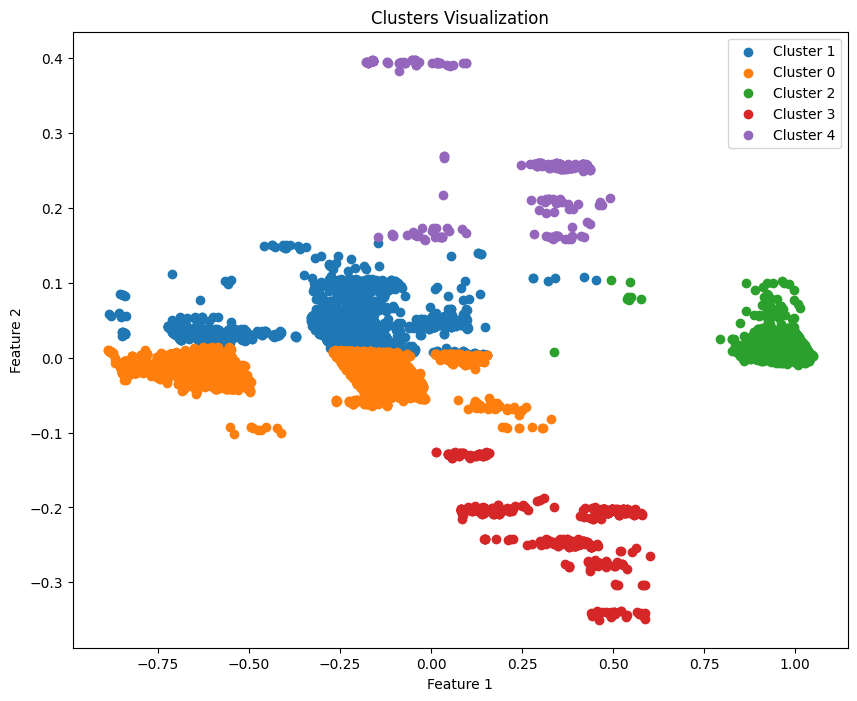

In [16]:
import matplotlib.pyplot as plt

# Plot the clusters using your two selected features
plt.figure(figsize=(10, 8))
for cluster in Submission.label.unique():
    mask = Submission.label == cluster
    plt.scatter(X[mask].iloc[:, 0], X[mask].iloc[:, 1], label=f'Cluster {cluster}')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Clusters Visualization')
plt.legend()
plt.show()

In [17]:
Submission = pd.read_csv('/content/Submission.csv', delimiter = ',', index_col = 'idx')
Submission

,label
idx,
0,2
1,0
2,0
3,0
4,1
...,...
19915,0
19916,0
19917,0


In [18]:
Submission.value_counts()

,count
label,
0,9473
2,8224
4,765
1,300
3,271


In [19]:
Submission.label = Submission.label.map({0: 0, 2: 1, 1: 2, 4: 3, 3: 4})

In [20]:
Submission.value_counts()

,count
label,
0,9473
1,8224
3,765
2,300
4,271


In [21]:
Submission.to_csv('/content/My_Submission.csv',index=True)

In [22]:
!kaggle competitions submit -c urfusf2024clustering -f My_Submission.csv -m "Random Numbers"

100% 138k/138k [00:00<00:00, 250kB/s]
Successfully submitted to UrFU_SF_2024_Clustering